In [ ]:
import pandas as pd

# 1. Load the Features (The Data)
# This file has no header, so we tell pandas to create one: txId, timestep, and feature_1...feature_165
features_df = pd.read_csv('elliptic_txs_features.csv', header=None)

# Rename columns for clarity
# Column 0 is txId, Column 1 is Timestep, the rest are features
col_names = ['txId', 'timestep'] + [f'feature_{i}' for i in range(165)]
features_df.columns = col_names

# 2. Load the Classes (The Labels)
classes_df = pd.read_csv('elliptic_txs_classes.csv')

# 3. Merge them together
# We combine them based on the 'txId' column
df = pd.merge(features_df, classes_df, on='txId')

# 4. Clean the Data
# The dataset has many 'unknown' labels. We need to remove them.
# We only keep rows where class is '1' (Scam) or '2' (Legit)
df = df[df['class'] != 'unknown']

# Convert labels to numbers for the model
# '1' (Illicit) becomes 1 (Scam)
# '2' (Licit) becomes 0 (Legit)
df['label'] = df['class'].apply(lambda x: 1 if x == '1' else 0)

# Drop the original 'class' column as we have our new 'label' column
df = df.drop(['class', 'txId', 'timestep'], axis=1)

print("Data is ready!")
print(df['label'].value_counts())
df.head()

Data is ready!
label
0    1992
1      13
Name: count, dtype: int64


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,label
3,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,-0.115831,0.043598,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
9,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,-0.144554,0.020069,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,0
10,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,-0.144108,-0.049707,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
11,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,-0.147643,-0.049707,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
16,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,-0.169115,-0.047227,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,0


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Split Data
X = df.drop('label', axis=1) # Features
y = df['label']              # Target (Scam or Legit)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = XGBClassifier()
model.fit(X_train, y_train)

# Check Accuracy
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       395
           1       1.00      0.50      0.67         6

    accuracy                           0.99       401
   macro avg       1.00      0.75      0.83       401
weighted avg       0.99      0.99      0.99       401



<Figure size 1000x800 with 0 Axes>

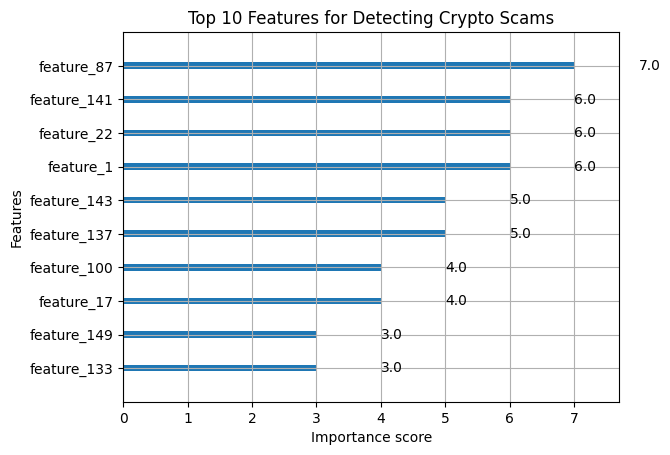

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Set the size of the plot
plt.figure(figsize=(10, 8))

# Plot the top 10 most important features
plot_importance(model, max_num_features=10)
plt.title("Top 10 Features for Detecting Crypto Scams")
plt.show()

In [ ]:
# Calculate the ratio of Legit to Scam
ratio = len(df[df['label'] == 0]) / len(df[df['label'] == 1])

print(f"Legit to Scam Ratio: {ratio:.2f}")

# Retrain the model with 'scale_pos_weight'
model_improved = XGBClassifier(scale_pos_weight=ratio, use_label_encoder=False, eval_metric='logloss')
model_improved.fit(X_train, y_train)

# Check new results
new_preds = model_improved.predict(X_test)
print(classification_report(y_test, new_preds))

Legit to Scam Ratio: 153.23


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:40:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       395
           1       0.83      0.83      0.83         6

    accuracy                           1.00       401
   macro avg       0.92      0.92      0.92       401
weighted avg       1.00      1.00      1.00       401



In [ ]:
import joblib

# Save the model to a file
joblib.dump(model_improved, 'rug_pull_detector.pkl')

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import pandas as pd
import joblib

# 1. Save the model (if you haven't already)
joblib.dump(model_improved, 'rug_pull_detector.pkl')

# 2. Save the "Test" data so we can use it in the app
# We save X_test (the features) and y_test (the actual answers) to compare later
X_test.to_csv('test_transactions.csv', index=False)
y_test.to_csv('test_labels.csv', index=False)

print("Files saved: rug_pull_detector.pkl, test_transactions.csv")

Files saved: rug_pull_detector.pkl, test_transactions.csv
